# Raw SVI diagnostics

Fit one Raw SVI slice per expiry to the screened SPX midpoint-IV panel. This notebook summarizes calibration, visualizes representative smiles and the fitted surface, and checks residuals, held-out strikes, calibration stability, butterfly conditions, and calendar monotonicity. The checks are diagnostics; sampled grids do not prove absence of arbitrage.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.raw_svi import (
    fit_raw_svi_surface,
    raw_svi_butterfly_diagnostic,
    raw_svi_total_variance,
)

PANEL_PATH = ROOT / 'data/processed/spx_iv_panel_2025-08-29.csv'
panel = pd.read_csv(PANEL_PATH, parse_dates=['quote_date', 'expiry_date'])
unconstrained_result = fit_raw_svi_surface(panel)
arbitrage_aware_result = fit_raw_svi_surface(panel, enforce_arbitrage=True)
observations = arbitrage_aware_result['observations'].copy()
parameters = arbitrage_aware_result['parameters_by_expiry'].copy()
observations['days_to_expiry'] = (observations['expiry_date'] - observations['quote_date']).dt.days
observations['fitted_iv'] = np.sqrt(observations['fitted_w'] / observations['time_to_expiry'])
observations['iv_residual'] = observations['fitted_iv'] - observations['mid_iv']
print(f'Input panel: {len(panel):,} rows; fitted OTM quotes: {len(observations):,}; expiries: {len(parameters)}')
print(f'Arbitrage-aware calibration: {arbitrage_aware_result["arbitrage_constrained"]}')

Input panel: 14,852 rows; fitted OTM quotes: 6,550; expiries: 38
Arbitrage-aware calibration: True


## Fit summary

Each expiry is calibrated independently by least squares in total variance, $w=\sigma^2\tau$. The table below reports the arbitrage-aware Raw SVI parameters, in-sample RMSE, and number of feasible calibration starts. The separate comparison shows the fit-cost of imposing the sampled butterfly conditions.

In [2]:
fit_summary = parameters.merge(
    observations.groupby('expiry_date').agg(
        days_to_expiry=('days_to_expiry', 'first'),
        n_quotes=('market_w', 'size'),
        k_min=('log_moneyness', 'min'),
        k_max=('log_moneyness', 'max'),
    ).reset_index(),
    on='expiry_date',
)
fit_summary = fit_summary[['expiry_date', 'days_to_expiry', 'n_quotes', 'a', 'b', 'rho', 'm', 'sigma', 'rmse', 'feasible_starts', 'k_min', 'k_max']]
display(fit_summary.assign(expiry_date=fit_summary['expiry_date'].dt.strftime('%Y-%m-%d')).round(6))
display(fit_summary[['n_quotes', 'rmse']].describe().round(6))

unconstrained_rmse = unconstrained_result['parameters_by_expiry'][['expiry_date', 'rmse']].rename(columns={'rmse': 'unconstrained_rmse'})
arbitrage_rmse = parameters[['expiry_date', 'rmse']].rename(columns={'rmse': 'arbitrage_aware_rmse'})
rmse_comparison = unconstrained_rmse.merge(arbitrage_rmse, on='expiry_date', validate='one_to_one')
rmse_comparison['rmse_increase'] = rmse_comparison['arbitrage_aware_rmse'] - rmse_comparison['unconstrained_rmse']
display(rmse_comparison.assign(expiry_date=rmse_comparison['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(rmse_comparison[['unconstrained_rmse', 'arbitrage_aware_rmse', 'rmse_increase']].mean().to_frame('mean_rmse').round(7))

,expiry_date,days_to_expiry,n_quotes,a,b,rho,m,sigma,rmse,feasible_starts,k_min,k_max
0,2025-09-02,4,112,-0.000282,0.010653,-0.650387,-0.023065,0.038354,0.000006,2,-0.094888,0.012343
1,2025-09-03,5,126,-0.000525,0.014918,-0.707687,-0.034515,0.054081,0.000006,2,-0.160975,0.016029
2,2025-09-04,6,133,-0.000682,0.017328,-0.749342,-0.043255,0.064835,0.000012,1,-0.179335,0.019820
3,2025-09-05,7,188,-0.001865,0.024203,-0.638365,-0.055407,0.106942,0.000024,1,-0.256562,0.027864
4,2025-09-08,10,138,-0.000760,0.020532,-0.877855,-0.063349,0.083448,0.000018,1,-0.236873,0.028503
5,2025-09-09,11,139,-0.001809,0.026512,-0.752549,-0.066540,0.111066,0.000025,1,-0.297553,0.032201
6,2025-09-10,12,141,-0.004400,0.035038,-0.538705,-0.055338,0.155469,0.000031,1,-0.340247,0.035804
7,2025-09-11,13,140,-0.001687,0.028520,-0.825318,-0.070605,0.112360,0.000017,1,-0.297809,0.043117
8,2025-09-12,14,185,-0.002354,0.031128,-0.733394,-0.062942,0.122087,0.000025,1,-0.385134,0.047238
9,2025-09-15,17,124,-0.004850,0.038593,-0.571728,-0.053266,0.161386,0.000033,1,-0.431620,0.042838


,n_quotes,rmse
count,38.000000,38.000000
mean,172.368421,0.000221
std,108.502440,0.000287
min,52.000000,0.000006
25%,106.750000,0.000032
50%,130.000000,0.000095
75%,187.250000,0.000229
max,472.000000,0.001210


,expiry_date,unconstrained_rmse,arbitrage_aware_rmse,rmse_increase
0,2025-09-02,0.000005,0.000006,1.000000e-06
1,2025-09-03,0.000006,0.000006,2.000000e-07
2,2025-09-04,0.000012,0.000012,0.000000e+00
3,2025-09-05,0.000024,0.000024,0.000000e+00
4,2025-09-08,0.000018,0.000018,0.000000e+00
5,2025-09-09,0.000025,0.000025,0.000000e+00
6,2025-09-10,0.000030,0.000030,0.000000e+00
7,2025-09-11,0.000017,0.000017,0.000000e+00
8,2025-09-12,0.000025,0.000025,0.000000e+00
9,2025-09-15,0.000033,0.000033,0.000000e+00


,mean_rmse
unconstrained_rmse,0.000127
arbitrage_aware_rmse,0.000220
rmse_increase,0.000093


## Representative 2D smiles

Select the available expiries nearest 7, 30, 90, and 300 DTE. Points are screened market observations; each line is that expiry's fitted Raw SVI total variance curve. The line is shown only over the observed $k$ range, so this view does not disguise extrapolation as market fit.

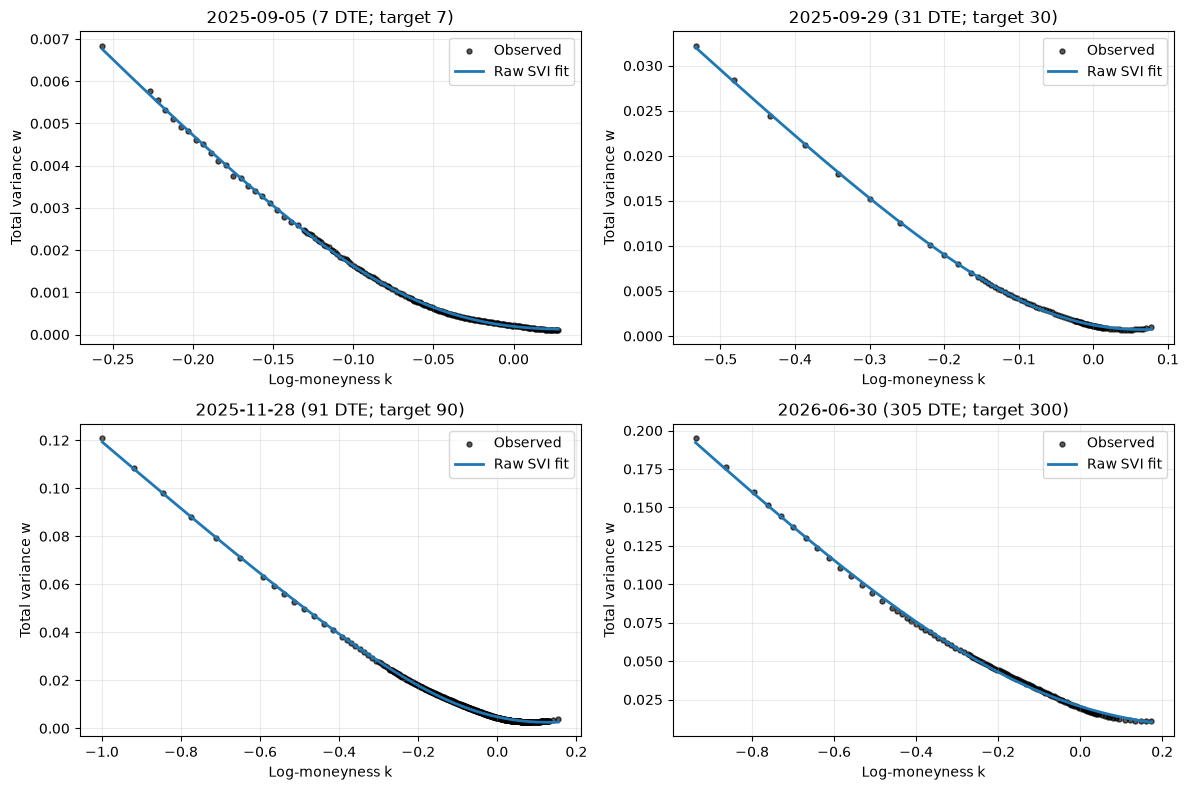

In [3]:
expiry_info = observations[['expiry_date', 'days_to_expiry']].drop_duplicates().sort_values('days_to_expiry')
selected_expiries = []
for target in [7, 30, 90, 300]:
    selected = expiry_info.iloc[(expiry_info['days_to_expiry'] - target).abs().argmin()]
    if selected['expiry_date'] not in [row['expiry_date'] for row in selected_expiries]:
        selected_expiries.append({'target_dte': target, **selected.to_dict()})

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for ax, selected in zip(axes.flat, selected_expiries):
    expiry = selected['expiry_date']
    rows = observations.loc[observations['expiry_date'].eq(expiry)]
    params = parameters.loc[parameters['expiry_date'].eq(expiry)].iloc[0]
    k_grid = np.linspace(rows['log_moneyness'].min(), rows['log_moneyness'].max(), 400)
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    ax.scatter(rows['log_moneyness'], rows['market_w'], s=13, color='black', alpha=0.65, label='Observed')
    ax.plot(k_grid, raw_svi_total_variance(k_grid, *p), color='tab:blue', lw=2, label='Raw SVI fit')
    ax.set(title=f'{expiry.date()} ({selected["days_to_expiry"]} DTE; target {selected["target_dte"]})', xlabel='Log-moneyness k', ylabel='Total variance w')
    ax.grid(alpha=0.25)
    ax.legend()
for ax in axes.flat[len(selected_expiries):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Observed and fitted 3D total-variance surface

Rotate the figure to inspect the screened observations and the fitted expiry slices together. The mesh is evaluated only within each expiry's observed $k$ range; gaps between expiry ranges are left blank. The model is slice-by-slice Raw SVI, not a globally parameterized surface.

In [4]:
k_mesh_grid = np.linspace(observations['log_moneyness'].min(), observations['log_moneyness'].max(), 180)
expiry_days = fit_summary['days_to_expiry'].to_numpy()
w_mesh = np.full((len(fit_summary), len(k_mesh_grid)), np.nan)
for i, params in fit_summary.iterrows():
    inside = (k_mesh_grid >= params['k_min']) & (k_mesh_grid <= params['k_max'])
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    w_mesh[i, inside] = raw_svi_total_variance(k_mesh_grid[inside], *p)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=k_mesh_grid, y=expiry_days, z=w_mesh, colorscale='Viridis', opacity=0.68,
    connectgaps=False, name='Fitted Raw SVI', colorbar=dict(title='Fitted w'),
))
fig.add_trace(go.Scatter3d(
    x=observations['log_moneyness'], y=observations['days_to_expiry'], z=observations['market_w'],
    mode='markers', marker=dict(size=2, color='black', opacity=0.6), name='Observed w',
    customdata=np.column_stack([observations['fitted_w'], observations['residual_w']]),
    hovertemplate='k=%{x:.3f}<br>DTE=%{y:.0f}<br>Observed w=%{z:.5f}<br>Fitted w=%{customdata[0]:.5f}<br>Residual=%{customdata[1]:+.5f}<extra></extra>',
))
fig.update_layout(title='Observed quotes and fitted Raw SVI slices', width=1000, height=750, scene=dict(xaxis_title='Log-moneyness k', yaxis_title='Days to expiry', zaxis_title='Total variance w'))
fig.show()

## Residual diagnostics

Residuals are fitted minus observed total variance. Look for systematic patterns with moneyness, maturity, or fitted level; a low aggregate RMSE can conceal structured errors. The second plot expresses errors in IV points for easier market interpretation.

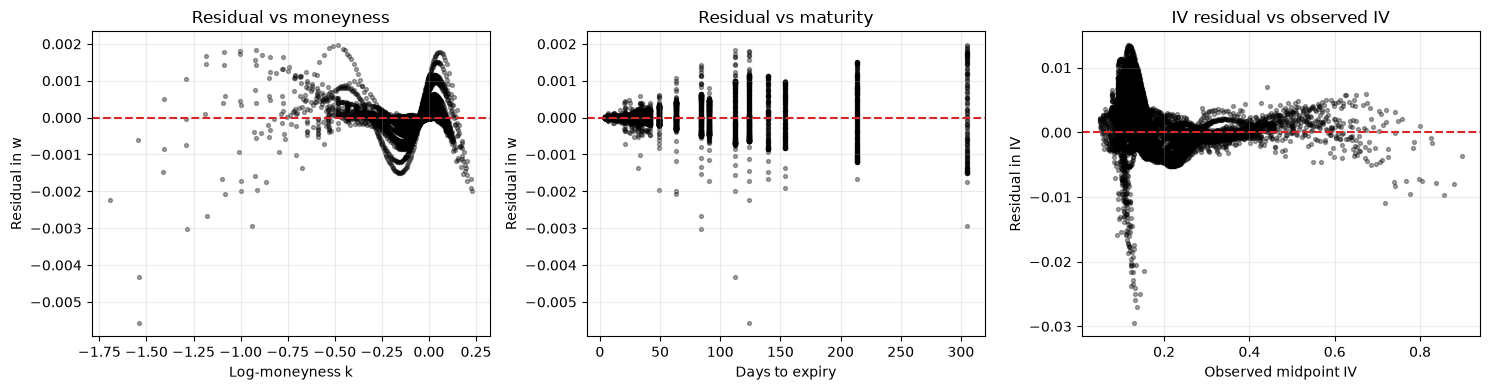

,residual_w,iv_residual
count,6550.000000,6550.000000
mean,0.000017,0.000625
std,0.000386,0.004433
min,-0.005560,-0.029424
25%,-0.000071,-0.002115
50%,0.000000,0.000007
75%,0.000088,0.002660
max,0.001964,0.013477


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(observations['log_moneyness'], observations['residual_w'], s=8, alpha=0.35, color='black')
axes[0].axhline(0, color='tab:red', ls='--')
axes[0].set(xlabel='Log-moneyness k', ylabel='Residual in w', title='Residual vs moneyness')
axes[1].scatter(observations['days_to_expiry'], observations['residual_w'], s=8, alpha=0.35, color='black')
axes[1].axhline(0, color='tab:red', ls='--')
axes[1].set(xlabel='Days to expiry', ylabel='Residual in w', title='Residual vs maturity')
axes[2].scatter(observations['mid_iv'], observations['iv_residual'], s=8, alpha=0.35, color='black')
axes[2].axhline(0, color='tab:red', ls='--')
axes[2].set(xlabel='Observed midpoint IV', ylabel='Residual in IV', title='IV residual vs observed IV')
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
display(observations[['residual_w', 'iv_residual']].describe().round(6))

## Held-out-strike validation

Within each expiry, sort by $k$ and hold out every fifth quote. Fit on the remaining quotes and evaluate the withheld strikes. This tests interpolation across the observed smile; it does not test maturity extrapolation. Compare train and test RMSE per expiry to spot overfitting.

In [6]:
holdout_rows = []
for expiry, rows in observations.groupby('expiry_date', sort=True):
    rows = rows.sort_values('log_moneyness').reset_index(drop=True)
    test_mask = np.arange(len(rows)) % 5 == 0
    train, test = rows.loc[~test_mask].copy(), rows.loc[test_mask].copy()
    fitted = fit_raw_svi_surface(train, enforce_arbitrage=True)['parameters_by_expiry'].iloc[0]
    p = [fitted[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    test_w = raw_svi_total_variance(test['log_moneyness'].to_numpy(), *p)
    holdout_rows.append({
        'expiry_date': expiry, 'n_train': len(train), 'n_test': len(test),
        'train_rmse_w': fitted['rmse'],
        'test_rmse_w': float(np.sqrt(np.mean((test_w - test['market_w'].to_numpy()) ** 2))),
    })
holdout = pd.DataFrame(holdout_rows)
display(holdout.assign(expiry_date=holdout['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(holdout[['train_rmse_w', 'test_rmse_w']].describe().round(7))

,expiry_date,n_train,n_test,train_rmse_w,test_rmse_w
0,2025-09-02,89,23,0.000006,0.000006
1,2025-09-03,100,26,0.000005,0.000010
2,2025-09-04,106,27,0.000012,0.000016
3,2025-09-05,150,38,0.000023,0.000031
4,2025-09-08,110,28,0.000016,0.000030
5,2025-09-09,111,28,0.000013,0.000077
6,2025-09-10,112,29,0.000018,0.000095
7,2025-09-11,112,28,0.000017,0.000023
8,2025-09-12,148,37,0.000025,0.000023
9,2025-09-15,99,25,0.000020,0.000126


,train_rmse_w,test_rmse_w
count,38.000000,38.000000
mean,0.000207,0.000286
std,0.000282,0.000326
min,0.000005,0.000006
25%,0.000027,0.000081
50%,0.000087,0.000161
75%,0.000192,0.000390
max,0.001178,0.001380


## Calibration stability

Refit representative expiries from deliberately different starting parameters. Compare both parameter estimates and the fitted curve over the observed strike range. Parameters can vary while the fitted curves remain close, indicating weak parameter identification rather than materially different fits.

In [7]:
stability_rows = []
for selected in selected_expiries:
    expiry = selected['expiry_date']
    rows = observations.loc[observations['expiry_date'].eq(expiry)]
    k = rows['log_moneyness'].to_numpy()
    grid = np.linspace(k.min(), k.max(), 300)
    min_w = float(rows['market_w'].min())
    starts = {
        'default': None,
        'negative_skew': [max(min_w - 0.01, -1.0), 0.03, -0.8, 0.0, 0.05],
        'symmetric': [max(min_w - 0.01, -1.0), 0.15, 0.0, 0.0, 0.2],
        'positive_skew': [max(min_w - 0.01, -1.0), 0.3, 0.7, 0.0, 0.35],
    }
    reference = None
    for name, start in starts.items():
        try:
            params = fit_raw_svi_surface(rows, initial_guess=start, enforce_arbitrage=True)['parameters_by_expiry'].iloc[0]
            p = [params[col] for col in ['a', 'b', 'rho', 'm', 'sigma']]
            curve = raw_svi_total_variance(grid, *p)
            if reference is None: reference = curve
            stability_rows.append({
                'expiry_date': expiry, 'start': name, 'rmse_w': params['rmse'],
                'max_abs_curve_difference': float(np.max(np.abs(curve - reference))),
                **dict(zip(['a', 'b', 'rho', 'm', 'sigma'], p)),
            })
        except ValueError as error:
            stability_rows.append({'expiry_date': expiry, 'start': name, 'error': str(error)})
stability = pd.DataFrame(stability_rows)
display(stability.assign(expiry_date=stability['expiry_date'].dt.strftime('%Y-%m-%d')).round(6))

,expiry_date,start,rmse_w,max_abs_curve_difference,a,b,rho,m,sigma
0,2025-09-05,default,0.000024,0.000000,-0.001865,0.024203,-0.638365,-0.055407,0.106942
1,2025-09-05,negative_skew,0.000024,0.000000,-0.001866,0.024204,-0.638354,-0.055407,0.106944
2,2025-09-05,symmetric,0.000024,0.000000,-0.001866,0.024204,-0.638355,-0.055407,0.106944
3,2025-09-05,positive_skew,0.000024,0.000000,-0.001865,0.024203,-0.638369,-0.055407,0.106941
4,2025-09-29,default,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
5,2025-09-29,negative_skew,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
6,2025-09-29,symmetric,0.000090,0.000000,-0.011729,0.058853,-0.357767,-0.020930,0.226514
7,2025-09-29,positive_skew,0.000090,0.000000,-0.011729,0.058852,-0.357796,-0.020935,0.226514
8,2025-11-28,default,0.000345,0.000000,-0.030610,0.105164,-0.390122,-0.015524,0.342032
9,2025-11-28,negative_skew,0.000345,0.000000,-0.030611,0.105168,-0.390076,-0.015514,0.342031


## Butterfly diagnostics

For each expiry, evaluate total-variance positivity, Durrleman's $g(k)$ on the quoted interval and on the wider $[-5,5]$ grid, plus both wing constraints $b(1+\rho)<2$ and $b(1-\rho)<2$. A violation only on the wide grid is an extrapolation warning; a violation within quoted strikes is more directly relevant. Grid checks are not a formal proof over all real $k$.

In [8]:
butterfly_rows = []
wide_grid = np.linspace(-5.0, 5.0, 4001)
for _, params in parameters.iterrows():
    rows = observations.loc[observations['expiry_date'].eq(params['expiry_date'])]
    p = [params[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    quoted_grid = np.linspace(rows['log_moneyness'].min(), rows['log_moneyness'].max(), 1001)
    quoted = raw_svi_butterfly_diagnostic(*p, quoted_grid)
    wide = raw_svi_butterfly_diagnostic(*p, wide_grid)
    butterfly_rows.append({
        'expiry_date': params['expiry_date'], 'k_min': quoted_grid.min(), 'k_max': quoted_grid.max(),
        'min_g_quoted': quoted['minimum_g_on_grid'], 'min_g_wide': wide['minimum_g_on_grid'],
        'g_nonnegative_quoted': quoted['g_nonnegative_on_grid'],
        'g_nonnegative_wide': wide['g_nonnegative_on_grid'],
        'variance_nonnegative': wide['nonnegative_total_variance'],
        'left_wing_slope': wide['left_wing_slope'], 'left_wing_pass': wide['left_wing_condition'],
        'right_wing_slope': wide['right_wing_slope'], 'right_wing_pass': wide['right_wing_condition'],
    })
butterfly = pd.DataFrame(butterfly_rows)
display(butterfly.assign(expiry_date=butterfly['expiry_date'].dt.strftime('%Y-%m-%d')).round(7))
display(butterfly[['g_nonnegative_quoted', 'g_nonnegative_wide', 'variance_nonnegative', 'left_wing_pass', 'right_wing_pass']].mean())

,expiry_date,k_min,k_max,min_g_quoted,min_g_wide,g_nonnegative_quoted,g_nonnegative_wide,variance_nonnegative,left_wing_slope,left_wing_pass,right_wing_slope,right_wing_pass
0,2025-09-02,-0.094889,0.012343,2.790000e-05,4.930000e-05,True,True,True,0.017581,True,0.003724,True
1,2025-09-03,-0.160975,0.016029,1.000000e-07,1.500000e-06,True,True,True,0.025476,True,0.004361,True
2,2025-09-04,-0.179335,0.019820,4.458900e-03,4.460300e-03,True,True,True,0.030312,True,0.004343,True
3,2025-09-05,-0.256562,0.027864,1.714780e-02,1.715680e-02,True,True,True,0.039654,True,0.008753,True
4,2025-09-08,-0.236873,0.028503,2.010980e-02,3.587300e-03,True,True,True,0.038556,True,0.002508,True
5,2025-09-09,-0.297553,0.032201,2.182380e-02,1.736850e-02,True,True,True,0.046463,True,0.006560,True
6,2025-09-10,-0.340247,0.035804,3.212930e-02,3.717900e-03,True,True,True,0.053913,True,0.016163,True
7,2025-09-11,-0.297809,0.043117,3.130510e-02,3.081200e-03,True,True,True,0.052059,True,0.004982,True
8,2025-09-12,-0.385134,0.047239,3.951860e-02,3.257230e-02,True,True,True,0.053958,True,0.008299,True
9,2025-09-15,-0.431620,0.042838,4.821090e-02,2.769000e-03,True,True,True,0.060658,True,0.016528,True


g_nonnegative_quoted    1.0
g_nonnegative_wide      1.0
variance_nonnegative    1.0
left_wing_pass          1.0
right_wing_pass         1.0
dtype: float64

## Calendar diagnostics

A basic calendar check compares total variance at fixed $k$ for adjacent expiries: longer-dated total variance should not be below shorter-dated total variance. This is checked on each adjacent pair's overlapping observed moneyness interval and on a wider common $k$ interval. The overlap check is the more market-relevant one; the wider check diagnoses model extrapolation. The arbitrage-aware calibration enforces butterfly conditions per expiry but does not impose calendar consistency across expiries, so violations may remain. This sampled check is not a complete static-arbitrage proof.

In [9]:
ordered = fit_summary.sort_values('days_to_expiry').reset_index(drop=True)
calendar_rows = []
for i in range(len(ordered) - 1):
    near, far = ordered.iloc[i], ordered.iloc[i + 1]
    overlap_lo = max(near['k_min'], far['k_min'])
    overlap_hi = min(near['k_max'], far['k_max'])
    if overlap_lo < overlap_hi:
        overlap_k = np.linspace(overlap_lo, overlap_hi, 501)
        near_p = [near[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
        far_p = [far[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
        diff_overlap = raw_svi_total_variance(overlap_k, *far_p) - raw_svi_total_variance(overlap_k, *near_p)
        n_violations = int((diff_overlap < -1e-10).sum())
        min_diff = float(diff_overlap.min())
    else:
        n_violations, min_diff = np.nan, np.nan
    wide_k = np.linspace(-0.5, 0.5, 1001)
    near_p = [near[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    far_p = [far[name] for name in ['a', 'b', 'rho', 'm', 'sigma']]
    diff_wide = raw_svi_total_variance(wide_k, *far_p) - raw_svi_total_variance(wide_k, *near_p)
    calendar_rows.append({
        'near_expiry': near['expiry_date'], 'near_dte': near['days_to_expiry'],
        'far_expiry': far['expiry_date'], 'far_dte': far['days_to_expiry'],
        'overlap_k_min': overlap_lo, 'overlap_k_max': overlap_hi,
        'overlap_min_w_difference': min_diff, 'overlap_violation_points': n_violations,
        'wide_min_w_difference': float(diff_wide.min()),
        'wide_violation_points': int((diff_wide < -1e-10).sum()),
    })
calendar = pd.DataFrame(calendar_rows)
display(calendar.assign(near_expiry=calendar['near_expiry'].dt.strftime('%Y-%m-%d'), far_expiry=calendar['far_expiry'].dt.strftime('%Y-%m-%d')).round(7))

,near_expiry,near_dte,far_expiry,far_dte,overlap_k_min,overlap_k_max,overlap_min_w_difference,overlap_violation_points,wide_min_w_difference,wide_violation_points
0,2025-09-02,4,2025-09-03,5,-0.094889,0.012343,0.000019,0,-0.000021,153
1,2025-09-03,5,2025-09-04,6,-0.160975,0.016029,0.000024,0,-0.000103,457
2,2025-09-04,6,2025-09-05,7,-0.179335,0.019820,0.000071,0,0.000064,0
3,2025-09-05,7,2025-09-08,10,-0.236873,0.027864,0.000006,0,-0.002464,470
4,2025-09-08,10,2025-09-09,11,-0.236873,0.028503,0.000038,0,0.000038,0
5,2025-09-09,11,2025-09-10,12,-0.297553,0.032201,0.000034,0,0.000034,0
6,2025-09-10,12,2025-09-11,13,-0.297809,0.035804,0.000028,0,-0.003855,455
7,2025-09-11,13,2025-09-12,14,-0.297809,0.043117,0.000048,0,0.000048,0
8,2025-09-12,14,2025-09-15,17,-0.385134,0.042838,0.000019,0,0.000019,0
9,2025-09-15,17,2025-09-16,18,-0.431620,0.042838,0.000047,0,0.000047,0
